In [14]:
from utilities.data_loader import load_data

train_prices, train_dates, test_prices, test_dates = load_data("./data/BTC-Daily.csv")

In [15]:
import pandas as pd

fixed_results = pd.read_csv("results/fixed_runs.csv")
random_results = pd.read_csv("results/random_runs.csv")

In [27]:
df = pd.concat([fixed_results, random_results], ignore_index=True)
display(df.groupby(['start_mode', 'algo', 'strategy'])['test_final_cash'].describe())
display(df.dtypes)
display(df.isnull().sum())
df['algo'].value_counts()
df['strategy'].value_counts()

count         mean           std  \
start_mode algo strategy                                            
fixed      abo  ema_independent   30.0  1482.449761  9.946911e+02   
                ema_shared        30.0  1815.812025  1.391740e+03   
                lma               30.0   683.138416  1.874051e+02   
                sma               30.0  1172.246028  1.247524e+01   
                weighted          30.0  4451.696568  8.170929e+02   
           aos  ema_independent   30.0  4271.851091  1.401703e+03   
                ema_shared        30.0  1894.032463  1.269024e+03   
                lma               30.0   794.096608  1.762895e+02   
                sma               30.0  1172.246028  1.247524e+01   
                weighted          30.0  4465.421449  8.302398e+02   
           gps  ema_independent   30.0  2328.667012  1.619273e+03   
                ema_shared        30.0  1831.888830  1.465627e+03   
                lma               30.0   879.139730  2.211375e+02   
                sma               30.0  1154.995486  2.163662e+02   
                weighted          30.0  2904.463557  1.852427e+03   
           mrfo ema_independent   30.0  1000.000000  0.000000e+00   
                ema_shared        30.0  1606.101452  1.366899e+03   
                lma               30.0   749.932663  2.003511e+02   
                sma               30.0  1180.275721  2.312607e-13   
                weighted          30.0  4329.082878  1.145655e+03   
           pso  ema_independent   30.0  3219.787103  1.460649e+03   
                ema_shared        30.0  2468.141499  2.176032e+03   
                lma               30.0   587.250644  1.358814e+02   
                sma               30.0  1129.063370  1.427064e+02   
                weighted          30.0  4813.352845  4.600434e+02   
           sos  ema_independent   30.0  3805.266377  1.285293e+03   
                ema_shared        30.0  2237.568295  1.698334e+03   
                lma               30.0   907.977724  0.000000e+00   
                sma               30.0  1180.275721  2.312607e-13   
                weighted          30.0  4580.572735  4.779724e+02   
random     abo  ema_independent   30.0  1571.547875  1.116958e+03   
                ema_shared        30.0  2408.182570  2.032666e+03   
                lma               30.0   742.495099  1.900496e+02   
                sma               30.0  1171.360121  1.461225e+01   
                weighted          30.0  4470.679547  9.703948e+02   
           aos  ema_independent   30.0  4463.359437  9.118198e+02   
                ema_shared        30.0  2559.524760  1.921990e+03   
                lma               30.0   804.376501  1.786373e+02   
                sma               30.0  1169.569464  1.333659e+01   
                weighted          30.0  4005.136358  1.513439e+03   
           gps  ema_independent   30.0  2659.173464  1.639742e+03   
                ema_shared        30.0  1819.939435  1.350677e+03   
                lma               30.0   939.179372  2.097797e+02   
                sma               30.0  1052.971553  2.542962e+02   
                weighted          30.0  1981.501366  1.767270e+03   
           mrfo ema_independent   30.0  1000.000000  0.000000e+00   
                ema_shared        30.0  1957.299567  2.195386e+03   
                lma               30.0   774.024220  1.953782e+02   
                sma               30.0  1180.275721  2.312607e-13   
                weighted          30.0  4158.145917  1.356560e+03   
           pso  ema_independent   30.0  3321.946476  1.404307e+03   
                ema_shared        30.0  2125.613944  1.431415e+03   
                lma               30.0   684.673058  1.762060e+02   
                sma               30.0  1063.073796  2.119179e+02   
                weighted          30.0  4464.471933  1.099632e+03   
           sos  ema_independent   30.0  4148.739220  1.006412e+03   
                ema_shared     

algo                  object
strategy              object
run_id                 int64
start_mode            object
best_fitness         float64
final_cash           float64
test_final_cash      float64
epoch_count            int64
runtime_ms           float64
early_stopped           bool
best_params           object
hyperparams           object
equity_curve          object
test_equity_curve     object
dtype: object

algo                 0
strategy             0
run_id               0
start_mode           0
best_fitness         0
final_cash           0
test_final_cash      0
epoch_count          0
runtime_ms           0
early_stopped        0
best_params          0
hyperparams          0
equity_curve         0
test_equity_curve    0
dtype: int64

strategy
sma                360
lma                360
ema_shared         360
ema_independent    360
weighted           360
Name: count, dtype: int64

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set once at the top of your notebook — applies to everything below
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Plot the bar for test_final_cash

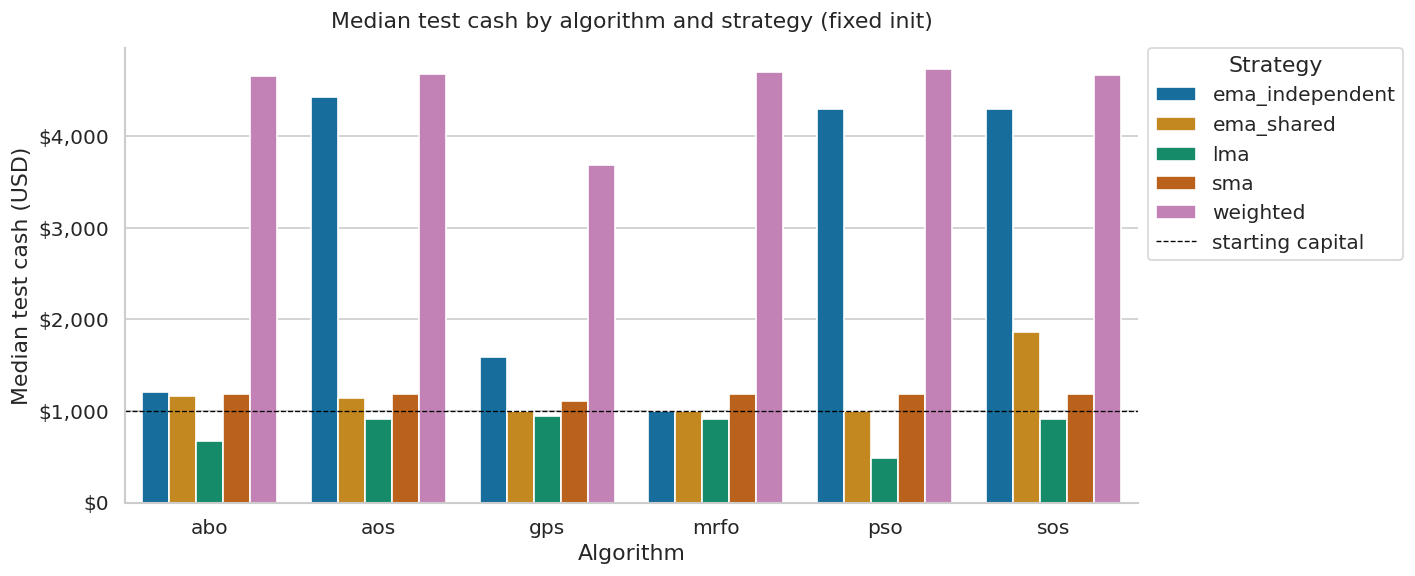

In [44]:

# Then your plot
fig, ax = plt.subplots(figsize=(12, 5))

medians = (df[df['start_mode'] == 'fixed']
           .groupby(['algo', 'strategy'])['test_final_cash']
           .median()
           .reset_index())

sns.barplot(
    data=medians,
    x='algo',
    y='test_final_cash',
    hue='strategy',
    palette='colorblind',   # distinguishable without relying on red/green
    ax=ax
)

# Reference line — starting capital
ax.axhline(1000, color='black', linewidth=0.8, linestyle='--', label='starting capital')

ax.set_title('Median test cash by algorithm and strategy (fixed init)', pad=12)
ax.set_xlabel('Algorithm')
ax.set_ylabel('Median test cash (USD)')
ax.legend(title='Strategy', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

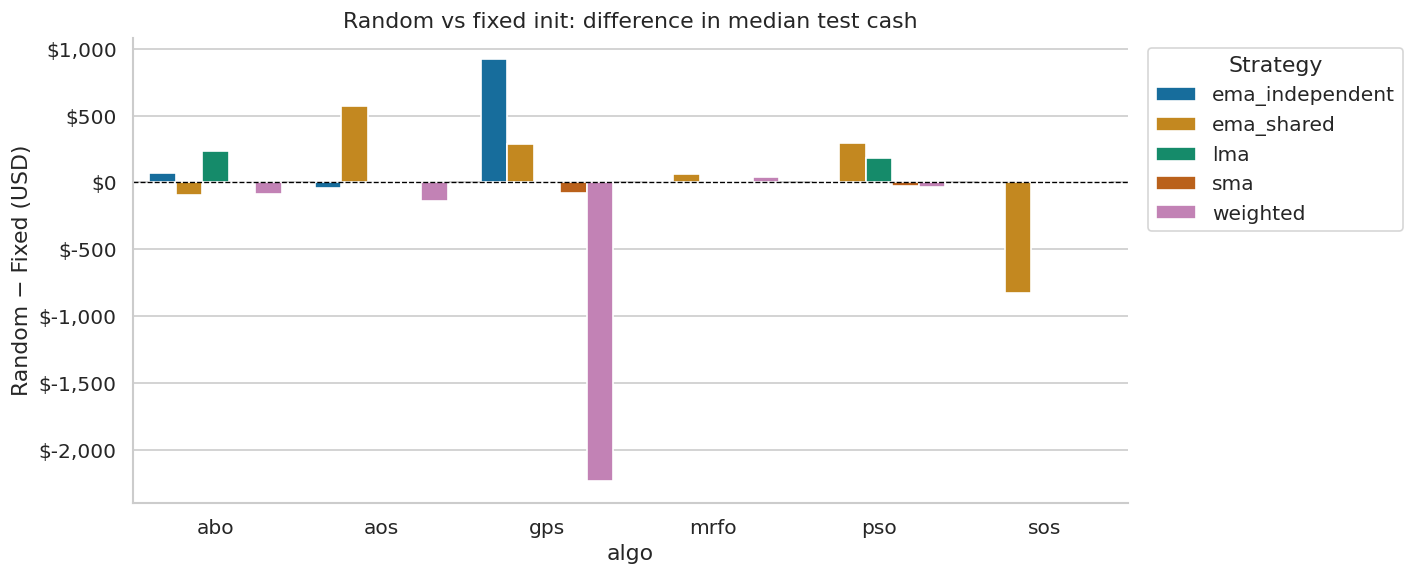

In [ ]:
# Pivot so fixed and random are columns, then compute difference
diff = (df.groupby(['start_mode', 'algo', 'strategy'])['test_final_cash']
        .median()
        .unstack('start_mode')   # start_mode becomes columns
        .reset_index())

diff['diff'] = diff['random'] - diff['fixed']

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=diff, x='algo', y='diff', hue='strategy', palette='colorblind', ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Random vs fixed init: difference in median test cash')
ax.set_ylabel('Random - Fixed (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Strategy', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

# Plot boxplot

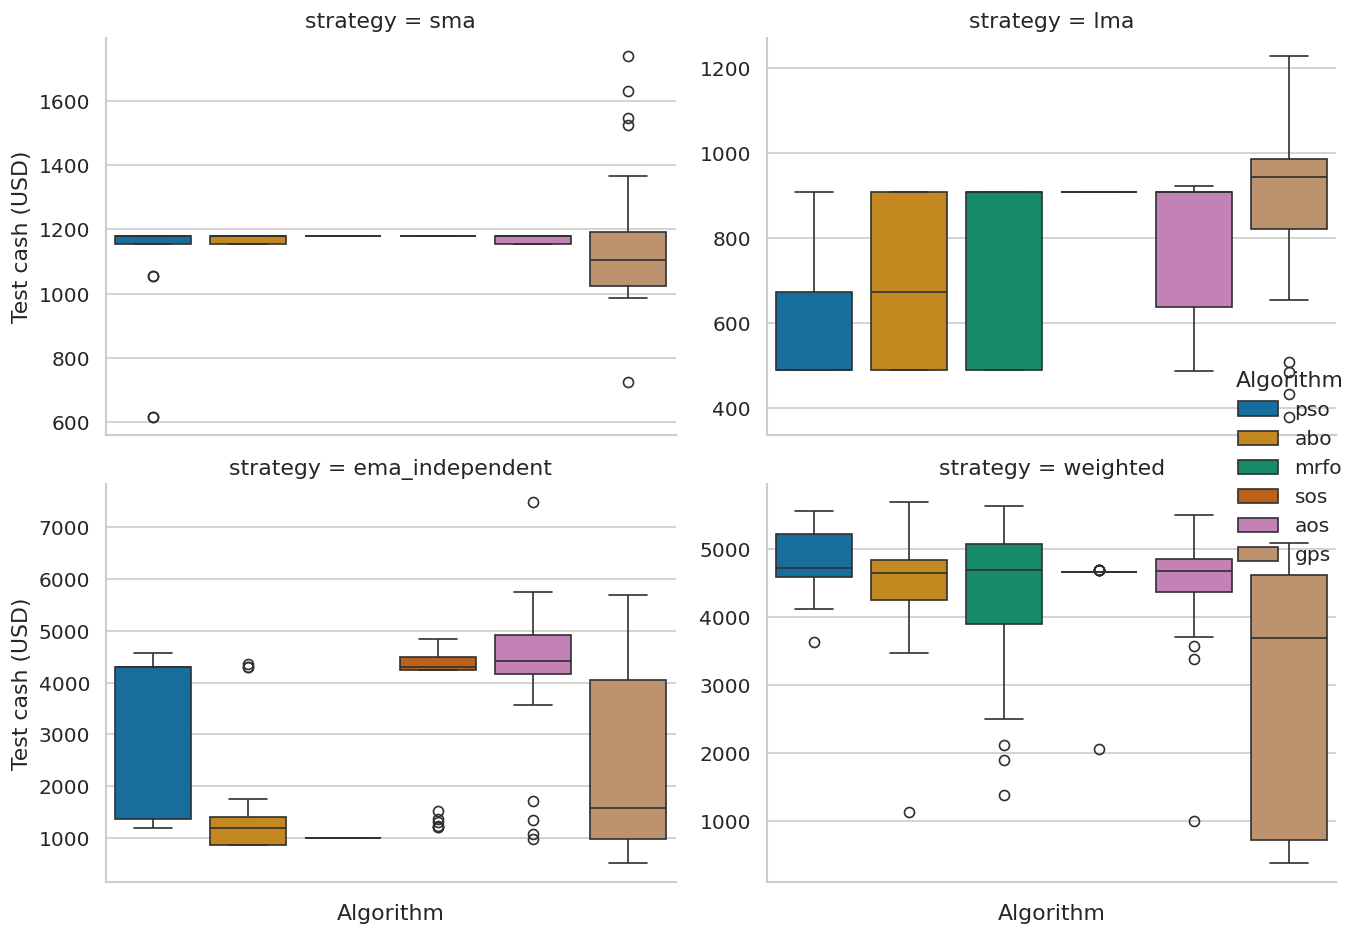

In [54]:
strategies_of_interest = ['sma', 'lma', 'ema_independent', 'weighted']

g = sns.FacetGrid(
    df[(df['start_mode'] == 'fixed') & 
       (df['strategy'].isin(strategies_of_interest))],
    col='strategy', col_wrap=2, height=4, aspect=1.3,
    sharey=False
)

g.map_dataframe(
    sns.boxplot,
    x='algo',
    y='test_final_cash',
    hue='algo',           # color by algo
    palette='colorblind',
    legend=True          # suppress per-subplot legends, we'll add one
)

g.set_xticklabels(rotation=45, ha='right')   # ha='right' stops labels from overlapping
g.set_titles(col_template='strategy = {col_name}')
g.set_axis_labels('Algorithm', 'Test cash (USD)')

# Add a shared legend
g.add_legend(title='Algorithm')

plt.tight_layout()

# Train vs Test Scatter

Text(0, 0.5, 'test cash')

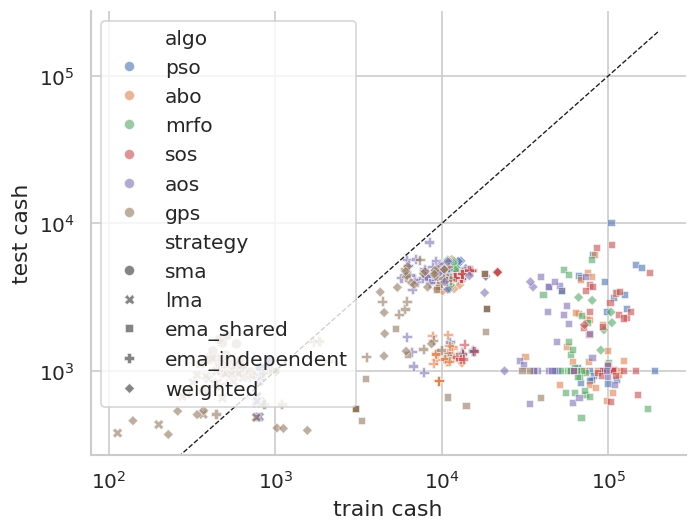

In [56]:
sns.scatterplot(
    data=df[df['start_mode'] == 'fixed'],
    x='final_cash',
    y='test_final_cash',
    hue='algo',
    style='strategy',
    alpha=0.6
)

# Add the diagonal — points on this line have zero overfit
import numpy as np
lim = df['final_cash'].max()
plt.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='train = test')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('train cash')
plt.ylabel('test cash')

# Rank Stability

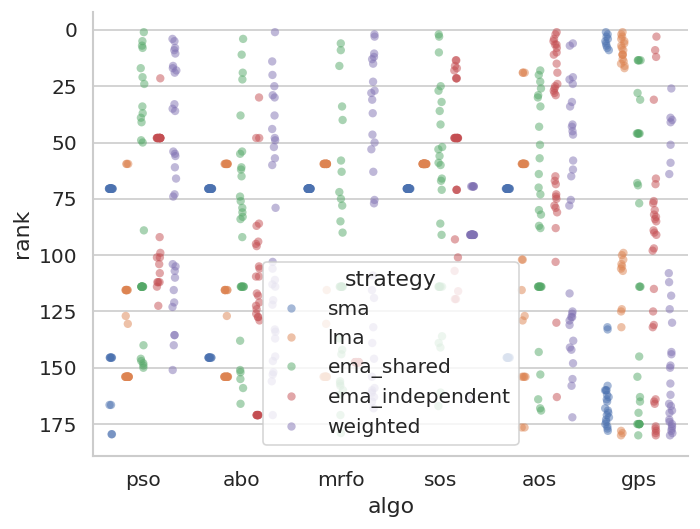

In [57]:
# Compute rank within each strategy (per start_mode if you want to compare them)
fixed_df_ranked = df[df['start_mode'] == 'fixed'].copy()

fixed_df_ranked['rank'] = fixed_df_ranked.groupby('strategy')['test_final_cash'] \
                            .rank(ascending=False, method='average')

# Now plot — each dot is one run, spread by strategy
sns.stripplot(
    data=fixed_df_ranked,
    x='algo',
    y='rank',
    hue='strategy',
    dodge=True,       # separates hue groups horizontally
    alpha=0.5,
    jitter=True       # spreads overlapping points
)
plt.gca().invert_yaxis()  # rank 1 at top

# Runtime vs Performance

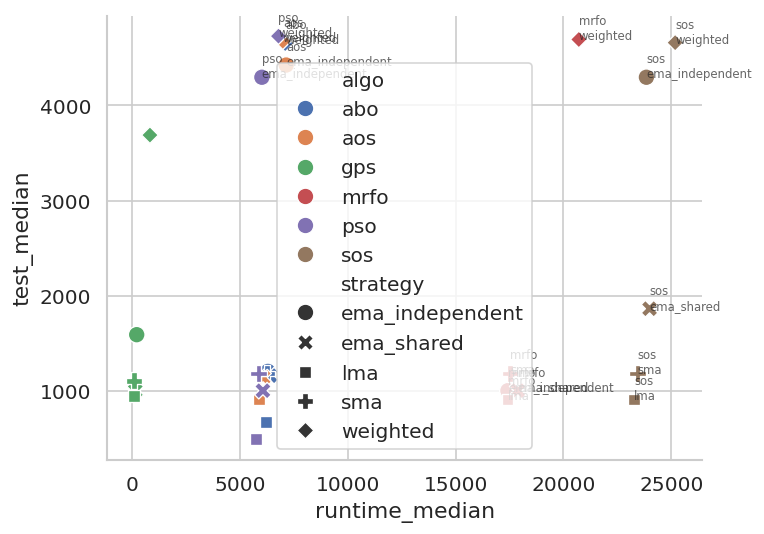

In [58]:
# Aggregate first — you want one point per algo/strategy, not 30 overlapping points
agg = df[df['start_mode'] == 'fixed'].groupby(['algo', 'strategy']).agg(
    test_median=('test_final_cash', 'median'),
    runtime_median=('runtime_ms', 'median')
).reset_index()

sns.scatterplot(
    data=agg,
    x='runtime_median',
    y='test_median',
    hue='algo',
    style='strategy',
    s=100
)

# Annotate outliers so you can read the plot
for _, row in agg.iterrows():
    if row['runtime_median'] > 15000 or row['test_median'] > 4000:
        plt.annotate(
            f"{row['algo']}\n{row['strategy']}",
            (row['runtime_median'], row['test_median']),
            fontsize=7, alpha=0.7
        )

# Cash per Time

Text(0, 0.5, 'test profit per ms of runtime')

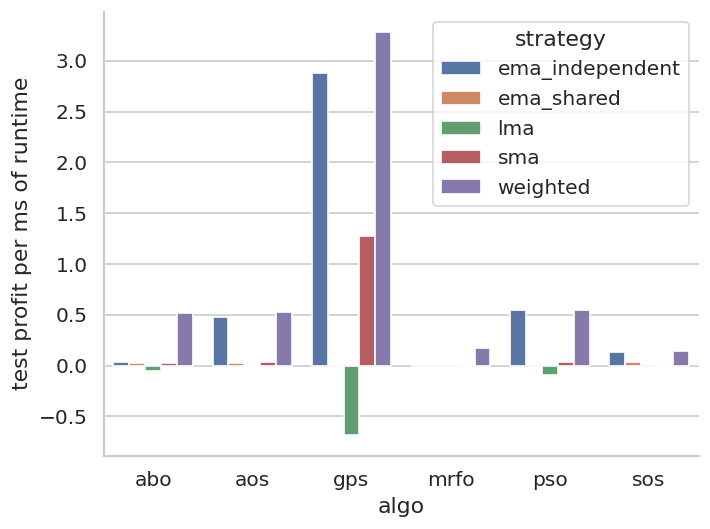

In [59]:
agg['cash_per_ms'] = (agg['test_median'] - 1000) / agg['runtime_median']

sns.barplot(
    data=agg,
    x='algo',
    y='cash_per_ms',
    hue='strategy'
)
plt.ylabel('test profit per ms of runtime')

# Aggregate and Save

In [25]:
agg_funcs = ["mean", "median", "std", lambda x: x.std() / x.mean(), "min", "max"]
agg_names  = ["mean", "median", "std", "cv", "min", "max"]

def summarise(df, cols):
    return (
        df.groupby(["strategy", "algo"])[cols]
        .agg(agg_funcs)
        .set_axis(
            pd.MultiIndex.from_product([cols, agg_names]),
            axis=1,
        )
    )

# Table 1 — cash performance
print("=== Fixed — Cash ===")
display(summarise(fixed_results, ["final_cash", "test_final_cash"]))

print("=== Random — Cash ===")
display(summarise(random_results, ["final_cash", "test_final_cash"]))

# Table 2 — runtime & epochs
print("=== Fixed — Runtime / Epochs ===")
display(summarise(fixed_results, ["runtime_ms", "epoch_count"]))

print("=== Random — Runtime / Epochs ===")
display(summarise(random_results, ["runtime_ms", "epoch_count"]))

=== Fixed — Cash ===


final_cash                               \
                               mean         median           std   
strategy        algo                                               
ema_independent abo    10317.896641    9991.589061   1066.836683   
                aos     7705.877321    7832.514110   1183.432799   
                gps     4915.222670    4940.993703   4024.844369   
                mrfo    1000.000000    1000.000000      0.000000   
                pso    12290.963688   11840.345246   1217.084658   
                sos    12918.128816   12938.121797   1140.329555   
ema_shared      abo    82168.473229   78174.956008  21848.893595   
                aos    56606.679039   49801.946667  21890.650415   
                gps    12375.956672   10163.254256  10185.346815   
                mrfo   67903.412265   63342.252923  22442.712670   
                pso    94238.920522   93613.792222  31989.411688   
                sos   104039.940608  104256.017908  25828.923580   
lma             abo      801.504087     800.109006     16.218467   
                aos      804.558194     809.916730     16.177486   
                gps      442.489450     447.107508    131.689226   
                mrfo     809.681552     818.928633     13.083071   
                pso      794.017424     800.109006     14.014979   
                sos      818.928633     818.928633      0.000000   
sma             abo      932.100655     932.497228      0.616131   
                aos      932.100655     932.497228      0.616131   
                gps      549.259155     560.937297    110.731669   
                mrfo     932.497228     932.497228      0.000000   
                pso      916.537442     932.497228     40.685151   
                sos      932.497228     932.497228      0.000000   
weighted        abo    11242.107016   11366.222821   1098.236748   
                aos    13388.575001   10705.403348   6678.842269   
                gps     5507.216992    6136.075156   3440.369535   
                mrfo   27209.928353   11762.864174  32410.214872   
                pso    12317.441389   12355.898862    776.557190   
                sos    23280.432494   21605.887574   9171.860264   

                                                                 \
                                cv           min            max   
strategy        algo                                              
ema_independent abo   1.033967e-01   8779.938889   12880.156559   
                aos   1.535753e-01   5678.182364   10581.451657   
                gps   8.188529e-01    301.897231   11212.022974   
                mrfo  0.000000e+00   1000.000000    1000.000000   
                pso   9.902272e-02  10401.387593   15303.773499   
                sos   8.827359e-02  11840.345246   15607.472864   
ema_shared      abo   2.659036e-01  31561.644080  123641.785050   
                aos   3.867150e-01  29400.243773  109032.203853   
                gps   8.229947e-01    442.936684   39184.820045   
                mrfo  3.305094e-01  40486.224985  171987.576407   
                pso   3.394501e-01  47146.875652  188575.414633   
                sos   2.482597e-01  61937.171352  175857.237391   
lma             abo   2.023504e-02    776.262975     818.928633   
                aos   2.010729e-02    767.322048     818.928633   
                gps   2.976099e-01    112.810855     768.263863   
                mrfo  1.615829e-02    772.378132     818.928633   
                pso   1.765072e-02    772.378132     818.928633   
                sos   2.823942e-16    818.928633     818.928633   
sma             abo   6.610130e-04    931.175319     932.497228   
                aos   6.610130e-04    931.175319     932.497228   
                gps   2.016019e-01    370.498784     917.966551   
                mrfo  2.480015e-16    932.497228     932.497228   
                pso   4.439006e-02    807.599450     932.497228   
                sos   2.480015e-16    

=== Random — Cash ===


final_cash                                            \
                               mean        median           std            cv   
strategy        algo                                                            
ema_independent abo    10584.622199  10623.588973   1694.288840  1.600708e-01   
                aos     7597.149160   7579.218699   1194.996610  1.572954e-01   
                gps     4560.538614   3983.504834   3763.420711  8.252141e-01   
                mrfo    1000.000000   1000.000000      0.000000  0.000000e+00   
                pso    12207.431274  11840.345246    985.173005  8.070273e-02   
                sos    12521.547488  12043.424346    779.085334  6.221957e-02   
ema_shared      abo    74415.837097  70136.982367  31210.114498  4.194015e-01   
                aos    54540.295677  50900.249889  19524.731154  3.579873e-01   
                gps    12830.074342   9250.498391  10288.301093  8.018894e-01   
                mrfo   73282.172973  70114.021053  19888.069732  2.713903e-01   
                pso    83749.678263  80166.940217  22819.602798  2.724739e-01   
                sos   103154.286533  98913.416283  25541.969023  2.476094e-01   
lma             abo      805.617011    810.606767     15.811860  1.962702e-02   
                aos      809.490718    817.548559     12.580155  1.554083e-02   
                gps      455.448948    445.030659    111.366974  2.445213e-01   
                mrfo     811.305765    818.928633     11.051188  1.362148e-02   
                pso      798.174548    800.109006     18.115138  2.269571e-02   
                sos      818.928633    818.928633      0.000000  2.823942e-16   
sma             abo      932.003386    932.497228      0.921778  9.890287e-04   
                aos      931.968464    932.497228      0.658671  7.067529e-04   
                gps      549.097905    585.147572    129.416966  2.356901e-01   
                mrfo     932.497228    932.497228      0.000000  2.480015e-16   
                pso      902.787919    931.175319     54.448261  6.031124e-02   
                sos      932.497228    932.497228      0.000000  2.480015e-16   
weighted        abo    11315.119002  11264.840733   1335.995023  1.180717e-01   
                aos    13719.287933  10670.006294   8376.645495  6.105744e-01   
                gps     4275.187584   4595.384863   3723.953310  8.710620e-01   
                mrfo   26547.702748  12340.451740  25836.783929  9.732211e-01   
                pso    12913.095203  12612.260756   1557.836845  1.206401e-01   
                sos    21605.887574  21605.887574      0.000000  5.137726e-16   

                                                  test_final_cash  \
                               min            max            mean   
strategy        algo                                                
ema_independent abo    5967.635840   13212.532212     1571.547875   
                aos    5775.187190   10023.161865     4463.359437   
                gps     293.736061   12939.690885     2659.173464   
                mrfo   1000.000000    1000.000000     1000.000000   
                pso   11075.521978   15303.773499     3321.946476   
                sos   11840.345246   14974.916499     4148.739220   
ema_shared      abo   42715.708292  200371.415733     2408.182570   
                aos   32799.075559  132228.769993     2559.524760   
                gps    2731.983453   44225.349012     1819.939435   
                mrfo  47075.826391  130135.597001     1957.299567   
                pso   47253.313227  139488.124842     2125.613944   
                sos   68570.623049  166099.708760     2145.608218   
lma             abo     776.262975     818.928633      742.495099   
                aos     775.807311     818.928633      804.376501   
                gps     181.754117     720.284866      939.179372   
                mrfo    776.262975     818.928633      774.024220   
                pso     772.378132     8

=== Fixed — Runtime / Epochs ===


runtime_ms                                      \
                              mean        median         std        cv   
strategy        algo                                                     
ema_independent abo    6281.424955   6292.029003  119.148100  0.018968   
                aos    7140.310453   7138.694514   65.578911  0.009184   
                gps     203.494518    204.577397   12.611050  0.061972   
                mrfo  17417.545915  17425.903897  115.200136  0.006614   
                pso    6010.137298   6011.291486   60.521352  0.010070   
                sos   23807.476532  23849.486768  197.897960  0.008312   
ema_shared      abo    6408.013834   6384.832939  104.240313  0.016267   
                aos    6069.213745   6067.885460   63.690108  0.010494   
                gps     142.608485    137.923320   15.047004  0.105513   
                mrfo  17878.391387  17881.258735  109.813109  0.006142   
                pso    6058.850682   6061.009810   60.304602  0.009953   
                sos   23995.634407  23996.702263  170.889320  0.007122   
lma             abo    6187.200935   6192.215271   86.624955  0.014001   
                aos    5880.059795   5879.264018   21.798285  0.003707   
                gps      83.880266     83.100026    3.323712  0.039624   
                mrfo  17400.275361  17410.242800  145.449679  0.008359   
                pso    5743.364176   5731.181752   45.018352  0.007838   
                sos   23265.903212  23273.322697   93.025063  0.003998   
sma             abo    6247.228911   6251.899832   64.590920  0.010339   
                aos    5840.733205   5839.180187   14.037662  0.002403   
                gps      82.482865     81.610188    4.255212  0.051589   
                mrfo  17530.279044  17520.109382   60.909352  0.003475   
                pso    5827.134777   5847.899997   68.549461  0.011764   
                sos   23419.333407  23427.691761  100.948445  0.004310   
weighted        abo    7098.579097   7092.985368  146.123139  0.020585   
                aos    6994.358024   6981.863531   59.743343  0.008542   
                gps     812.156337    819.030109  108.278874  0.133323   
                mrfo  20725.828905  20714.830777  294.051825  0.014188   
                pso    6781.955828   6781.858304   82.363614  0.012145   
                sos   25248.183852  25183.335651  331.775374  0.013141   

                                                 epoch_count                   \
                               min           max        mean median       std   
strategy        algo                                                            
ema_independent abo    5948.522140   6605.175978   51.000000   51.0  0.000000   
                aos    6978.012451   7267.631975   50.966667   51.0  0.182574   
                gps     174.354895    229.711759   24.933333   24.5  3.666562   
                mrfo  17152.305744  17669.882964   50.000000   50.0  0.000000   
                pso    5885.821431   6131.025673   51.000000   51.0  0.000000   
                sos   23405.197705  24158.511404   50.000000   50.0  0.000000   
ema_shared      abo    6167.686828   6575.212140   51.000000   51.0  0.000000   
                aos    5959.050960   6179.368427   50.933333   51.0  0.253708   
                gps     120.393522    188.239951   22.766667   22.5  3.212941   
                mrfo  17643.721711  18035.717080   50.000000   50.0  0.000000   
                pso    5949.037842   6188.530575   50.966667   51.0  0.182574   
                sos   23702.087390  24431.368904   50.000000   50.0  0.000000   
lma             abo    5967.785789   6373.964377   51.000000   51.0  0.000000   
                aos    5844.724434   5929.038625   51.000000   51.0  0.000000   
                gps      79.536722     90.143765   19.333333   19.0  1.446359   
                mrfo  17171.752073  17608.609802   50.000000   50.0  0.000000   
                pso    5684.018936   5844.

=== Random — Runtime / Epochs ===


runtime_ms                                      \
                              mean        median         std        cv   
strategy        algo                                                     
ema_independent abo    6083.349284   6078.749931  121.393407  0.019955   
                aos    7005.736001   7008.565425   51.063171  0.007289   
                gps     202.459395    198.815755   19.734294  0.097473   
                mrfo  17123.246614  17136.751638  134.951476  0.007881   
                pso    5811.331550   5811.323194   78.918271  0.013580   
                sos   23468.691357  23463.319949  113.984493  0.004857   
ema_shared      abo    6228.684584   6246.251397  114.809581  0.018432   
                aos    5952.023157   5956.634967   47.294316  0.007946   
                gps     148.562092    142.834833   19.630482  0.132137   
                mrfo  17571.360021  17564.884121   93.366468  0.005314   
                pso    5753.693956   5751.581747   59.702054  0.010376   
                sos   23598.617367  23596.406921  173.013877  0.007332   
lma             abo    6016.667640   6023.745949   79.498332  0.013213   
                aos    5788.475727   5791.525935   31.260426  0.005400   
                gps      82.983871     82.549638    3.808039  0.045889   
                mrfo  17270.174521  17284.191540  158.015214  0.009150   
                pso    5541.073612   5520.407186   88.631640  0.015995   
                sos   22977.497033  22976.998986  103.663392  0.004512   
sma             abo    6051.080358   6082.381506   77.500914  0.012808   
                aos    5777.418757   5774.195147   19.008027  0.003290   
                gps      82.416047     81.859188    3.582613  0.043470   
                mrfo  17187.041539  17211.395892   49.443168  0.002877   
                pso    5485.194892   5487.649190  101.958551  0.018588   
                sos   22686.291867  22666.293239  104.124308  0.004590   
weighted        abo    6891.753692   6911.926781  117.162443  0.017000   
                aos    6909.469424   6899.773128   48.267116  0.006986   
                gps     771.470782    771.961920  130.966411  0.169762   
                mrfo  20055.691264  20088.920916  423.283765  0.021105   
                pso    6620.614564   6605.867875   87.726640  0.013251   
                sos   24666.803931  24614.125106  278.257349  0.011281   

                                                 epoch_count                   \
                               min           max        mean median       std   
strategy        algo                                                            
ema_independent abo    5854.142053   6334.245649   51.000000   51.0  0.000000   
                aos    6900.488343   7092.156663   51.000000   51.0  0.000000   
                gps     169.379210    286.825886   25.466667   25.0  2.968029   
                mrfo  16803.647833  17291.636275   50.000000   50.0  0.000000   
                pso    5695.739539   5985.034074   51.000000   51.0  0.000000   
                sos   23271.503407  23776.846654   50.000000   50.0  0.000000   
ema_shared      abo    6030.846868   6426.245151   51.000000   51.0  0.000000   
                aos    5853.033667   6021.595390   51.000000   51.0  0.000000   
                gps     122.777151    193.548348   22.633333   22.0  3.123695   
                mrfo  17346.668670  17774.770216   50.000000   50.0  0.000000   
                pso    5639.005138   5866.414210   51.000000   51.0  0.000000   
                sos   23246.037077  24039.116893   50.000000   50.0  0.000000   
lma             abo    5836.935163   6214.429568   51.000000   51.0  0.000000   
                aos    5673.533560   5830.430782   50.966667   51.0  0.182574   
                gps      76.558850     93.100013   19.800000   20.0  2.023994   
                mrfo  16999.361087  17507.452591   50.000000   50.0  0.000000   
                pso    5400.616320   5694.

In [26]:
summary_fixed_cash    = summarise(fixed_results,  ["final_cash", "test_final_cash"])
summary_random_cash   = summarise(random_results, ["final_cash", "test_final_cash"])
summary_fixed_runtime = summarise(fixed_results,  ["runtime_ms", "epoch_count"])
summary_random_runtime = summarise(random_results, ["runtime_ms", "epoch_count"])

summary_fixed_cash.to_csv("results/summary_fixed_cash.csv")
summary_random_cash.to_csv("results/summary_random_cash.csv")
summary_fixed_runtime.to_csv("results/summary_fixed_runtime.csv")
summary_random_runtime.to_csv("results/summary_random_runtime.csv")

print("Summaries saved to results/")

Summaries saved to results/
